In [1]:
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
from collections import defaultdict

In [2]:
books_df = pd.read_csv(
    "../data/processed/books_master.csv",
    low_memory=False
)

train_df = pd.read_csv(
    "../data/processed/train_df.csv"
)

test_df = pd.read_csv(
    "../data/processed/test_df.csv"
)

print(books_df.shape)
print(train_df.shape)
print(test_df.shape)

(271360, 13)
(101908, 5)
(6197, 5)


In [3]:
with open(
    "../models/item_similarity_df.pkl",
    "rb"
) as f:
    item_similarity_df = pickle.load(f)

print(item_similarity_df.shape)

(9009, 9009)


In [4]:
with open(
    "../models/semantic_neighbors.pkl",
    "rb"
) as f:
    semantic_neighbors = pickle.load(f)

print(len(semantic_neighbors))

373


In [5]:
with open(
    "../models/hybrid_config.pkl",
    "rb"
) as f:
    hybrid_config = pickle.load(f)

print(hybrid_config)

{'cf_weight': 0.3, 'bpr_weight': 0.35, 'content_weight': 0.35, 'hit10': 0.08407293851863805}


In [6]:
import torch
import torch.nn as nn

class BPRModel(nn.Module):

    def __init__(self, n_users, n_books, embedding_dim=50):

        super().__init__()

        self.user_embedding = nn.Embedding(
            n_users,
            embedding_dim
        )

        self.book_embedding = nn.Embedding(
            n_books,
            embedding_dim
        )

        nn.init.normal_(
            self.user_embedding.weight,
            std=0.01
        )

        nn.init.normal_(
            self.book_embedding.weight,
            std=0.01
        )

    def forward(self, users, items):

        user_vecs = self.user_embedding(users)

        item_vecs = self.book_embedding(items)

        scores = (user_vecs * item_vecs).sum(dim=1)

        return scores

In [7]:
config = torch.load(
    "../models/bpr_config.pth",
    weights_only=False
)

model = BPRModel(
    n_users=int(config["n_users"]),
    n_books=int(config["n_books"]),
    embedding_dim=int(config["embedding_dim"])
)

model.load_state_dict(
    torch.load(
        "../models/bpr_model.pth",
        weights_only=True
    )
)

model.eval()

print("BPR Loaded")

BPR Loaded


In [8]:
user_history = (
    train_df
    .groupby("user_idx")["book_idx"]
    .apply(set)
    .to_dict()
)

book_idx_to_isbn = (
    train_df[
        ["book_idx", "ISBN"]
    ]
    .drop_duplicates()
    .set_index("book_idx")["ISBN"]
    .to_dict()
)

isbn_to_book_idx = {
    isbn: idx
    for idx, isbn
    in book_idx_to_isbn.items()
}

print(len(user_history))
print(len(book_idx_to_isbn))

6197
9009


In [9]:
book_author = (
    books_df[
        ["ISBN", "Book-Author"]
    ]
    .drop_duplicates()
)

book_author["book_idx"] = (
    book_author["ISBN"]
    .map(isbn_to_book_idx)
)

book_author = book_author.dropna()

author_groups = (
    book_author
    .groupby("Book-Author")["book_idx"]
    .apply(list)
    .to_dict()
)

author_neighbors = {}

for author, books in author_groups.items():

    for book in books:

        neighbors = []

        for other_book in books:

            if other_book != book:

                neighbors.append(
                    (int(other_book), 1.0)
                )

        author_neighbors[int(book)] = neighbors

print(len(author_neighbors))

9009


In [10]:
def normalize_scores(recommendations):

    if len(recommendations) == 0:
        return {}

    scores = [score for _, score in recommendations]

    min_score = min(scores)
    max_score = max(scores)

    if max_score == min_score:

        return {
            item: 1.0
            for item, _ in recommendations
        }

    return {
        item: (score - min_score)
        /
        (max_score - min_score)

        for item, score
        in recommendations
    }

In [11]:
from collections import defaultdict
import numpy as np
import pandas as pd

def recommend_cf(
    user_id,
    train_df,
    item_similarity_df,
    top_n=100,
    k=10
):

    user_ratings = train_df[
        train_df["user_idx"] == user_id
    ]

    scores = {}

    for _, row in user_ratings.iterrows():

        book = row["book_idx"]
        rating = row["Rating"]

        neighbors = (
            item_similarity_df[book]
            .sort_values(ascending=False)
            .iloc[1:k+1]
        )

        for sim_book, sim_score in neighbors.items():

            scores[sim_book] = (
                scores.get(sim_book, 0)
                + sim_score * rating
            )

    already_read = set(
        user_ratings["book_idx"]
    )

    recommendations = (
        pd.Series(scores)
        .drop(
            labels=already_read,
            errors="ignore"
        )
        .sort_values(
            ascending=False
        )
        .head(top_n)
    )

    return list(
        zip(
            recommendations.index.tolist(),
            recommendations.values.tolist()
        )
    )

In [12]:
import torch
import numpy as np

def recommend_bpr(
    user_idx,
    model,
    user_history,
    top_k=10
):

    model.eval()

    with torch.no_grad():

        user_vec = (
            model.user_embedding.weight[
                user_idx
            ]
        )

        book_vecs = (
            model.book_embedding.weight
        )

        scores = torch.matmul(
            book_vecs,
            user_vec
        )

        scores = scores.cpu().numpy()

    seen_books = user_history.get(
        user_idx,
        set()
    )

    scores[list(seen_books)] = -np.inf

    top_books = np.argsort(
        scores
    )[::-1][:top_k]

    return [
        (
            int(book_idx),
            float(scores[book_idx])
        )
        for book_idx in top_books
    ]

In [13]:
from collections import defaultdict

def recommend_content_combined(
    user_idx,
    user_history,
    author_neighbors,
    semantic_neighbors,
    book_idx_to_isbn,
    isbn_to_book_idx,
    top_n=100
):

    scores = defaultdict(float)

    # ---------- Author Part ----------
    seen_books = user_history.get(
        user_idx,
        set()
    )

    for book_idx in seen_books:

        for neighbor_idx, score in author_neighbors.get(
            book_idx,
            []
        ):

            if neighbor_idx in seen_books:
                continue

            scores[neighbor_idx] += 0.8 * score

    # ---------- Semantic Part ----------
    for book_idx in seen_books:

        isbn = book_idx_to_isbn.get(book_idx)

        if isbn not in semantic_neighbors:
            continue

        for neighbor_isbn, score in semantic_neighbors[isbn]:

            if neighbor_isbn not in isbn_to_book_idx:
                continue

            neighbor_idx = isbn_to_book_idx[
                neighbor_isbn
            ]

            if neighbor_idx in seen_books:
                continue

            scores[neighbor_idx] += 0.2 * score

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked[:top_n]

In [14]:
def hybrid_recommend(
    user_idx,
    top_n=10
):

    cf_recs = recommend_cf(
        user_idx,
        train_df,
        item_similarity_df,
        top_n=100,
        k=10
    )

    bpr_recs = recommend_bpr(
        user_idx,
        model,
        user_history,
        top_k=100
    )

    content_recs = recommend_content_combined(
        user_idx,
        user_history,
        author_neighbors,
        semantic_neighbors,
        book_idx_to_isbn,
        isbn_to_book_idx,
        top_n=100
    )

    cf_scores = normalize_scores(cf_recs)
    bpr_scores = normalize_scores(bpr_recs)
    content_scores = normalize_scores(content_recs)

    final_scores = defaultdict(float)

    all_books = (
        set(cf_scores.keys()) |
        set(bpr_scores.keys()) |
        set(content_scores.keys())
    )

    for book in all_books:

        final_scores[book] += (
            0.30 *
            cf_scores.get(book, 0)
        )

        final_scores[book] += (
            0.35 *
            bpr_scores.get(book, 0)
        )

        final_scores[book] += (
            0.35 *
            content_scores.get(book, 0)
        )

    ranked = sorted(
        final_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked[:top_n]

In [27]:
isbn_lookup = (
    books_df[
        ["ISBN","Book-Title","Book-Author"]
    ]
    .drop_duplicates("ISBN")
    .set_index("ISBN")
)

In [33]:
def recommend_books(
    user_idx,
    top_n=10
):

    recs = hybrid_recommend(
        user_idx,
        top_n=50
    )

    results = []
    seen_titles = set()

    for book_idx, score in recs:

        isbn = book_idx_to_isbn.get(book_idx)

        if isbn not in isbn_lookup.index:
            continue

        title = isbn_lookup.loc[
            isbn,
            "Book-Title"
        ]

        author = isbn_lookup.loc[
            isbn,
            "Book-Author"
        ]

        if title in seen_titles:
            continue

        seen_titles.add(title)

        results.append(
            (
                title,
                author,
                round(score,4)
            )
        )

        if len(results) == top_n:
            break

    return pd.DataFrame(
        results,
        columns=[
            "Title",
            "Author",
            "Score"
        ]
    )

In [34]:
recommend_books(
    user_idx=0,
    top_n=10
)

,Title,Author,Score
0,"The Arctic Incident (Artemis Fowl, Book 2)",Eoin Colfer,0.6670
1,Artemis Fowl: The Arctic Incident - Book #2 (A...,Eoin Colfer,0.5791
2,Basket Case,CARL HIAASEN,0.3500
3,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,0.3500
4,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,0.3500
5,"The Eternity Code (Artemis Fowl, Book 3)",Eoin Colfer,0.3500
6,The No. 1 Ladies' Detective Agency (Today Show...,Alexander McCall Smith,0.2610
7,American Gods,Neil Gaiman,0.2542
8,What Was She Thinking?: Notes on a Scandal: A ...,Zoe Heller,0.2499
9,The Bad Beginning (A Series of Unfortunate Eve...,Lemony Snicket,0.2480


In [38]:
results_df = pd.DataFrame({
    "Model": [
        "CF",
        "BPR",
        "Content",
        "Hybrid"
    ],
    "Hit@10": [
        0.059,
        0.0516,
        0.0490,
        0.08407
    ]
})

results_df

,Model,Hit@10
0,CF,0.05900
1,BPR,0.05160
2,Content,0.04900
3,Hybrid,0.08407


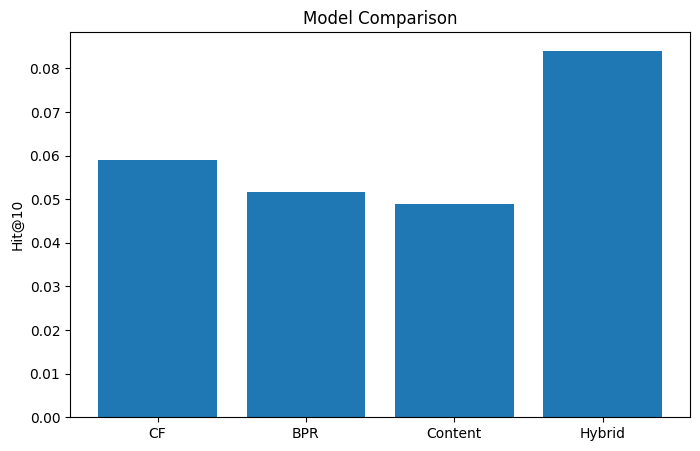

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Hit@10"]
)

plt.title("Model Comparison")
plt.ylabel("Hit@10")

plt.show()

In [40]:
recommended_books = set()

for user in test_df["user_idx"].unique():

    recs = hybrid_recommend(
        user,
        top_n=10
    )

    recommended_books.update(
        book
        for book, _
        in recs
    )

coverage = (
    len(recommended_books)
    /
    len(book_idx_to_isbn)
)

print("Coverage:", coverage)

Coverage: 0.714063714063714


In [43]:
recommend_books(0)

,Title,Author,Score
0,"The Arctic Incident (Artemis Fowl, Book 2)",Eoin Colfer,0.6670
1,Artemis Fowl: The Arctic Incident - Book #2 (A...,Eoin Colfer,0.5791
2,Basket Case,CARL HIAASEN,0.3500
3,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,0.3500
4,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,0.3500
5,"The Eternity Code (Artemis Fowl, Book 3)",Eoin Colfer,0.3500
6,The No. 1 Ladies' Detective Agency (Today Show...,Alexander McCall Smith,0.2610
7,American Gods,Neil Gaiman,0.2542
8,What Was She Thinking?: Notes on a Scandal: A ...,Zoe Heller,0.2499
9,The Bad Beginning (A Series of Unfortunate Eve...,Lemony Snicket,0.2480


In [44]:
recommend_books(10)

,Title,Author,Score
0,Girl with a Pearl Earring,Tracy Chevalier,0.3704
1,People of the Mist (The First North Americans ...,Kathleen O'Neal Gear,0.3500
2,"The Summoning God (The Anasazi Mysteries, Book 2)",Kathleen O'Neal Gear,0.3500
3,"The Visitant (The Anasazi Mysteries, Book 1)",Kathleen O'Neal Gear,0.3500
4,Snow Falling on Cedars,David Guterson,0.3463
5,People of the River (The First North Americans...,W. Michael Gear,0.3000
6,Wild Animus,Rich Shapero,0.2912
7,The Lovely Bones: A Novel,Alice Sebold,0.2894
8,She's Come Undone (Oprah's Book Club (Paperback)),Wally Lamb,0.2889
9,The Poisonwood Bible: A Novel,Barbara Kingsolver,0.2645


In [45]:
recommend_books(100)

,Title,Author,Score
0,Scientific Progress Goes 'Boink': A Calvin an...,Bill Watterson,0.7384
1,It's A Magical World: A Calvin and Hobbes Coll...,Bill Watterson,0.7301
2,Calvin and Hobbes,Bill Watterson,0.7251
3,The Revenge Of The Baby-Sat,Bill Watterson,0.6856
4,Homicidal Psycho Jungle Cat: A Calvin and Hobb...,Bill Watterson,0.6592
5,Attack Of The Deranged Mutant Killer Snow Goons,Bill Watterson,0.6297
6,There's Treasure Everywhere--A Calvin and Hobb...,Bill Watterson,0.5381
7,The Authoritative Calvin and Hobbes (Calvin an...,Bill Watterson,0.4940
8,The Indispensable Calvin And Hobbes,Bill Watterson,0.4747
9,The Calvin &amp; Hobbes Lazy Sunday Book,Bill Watterson,0.4372


In [46]:
import pickle

final_results = {
    "CF": 0.059,
    "BPR": 0.0516,
    "Content": 0.0490,
    "Hybrid": 0.08407,
    "Best Weights": {
        "CF": 0.30,
        "BPR": 0.35,
        "Content": 0.35
    }
}

with open(
    "../models/final_results.pkl",
    "wb"
) as f:
    pickle.dump(final_results, f)